### Validation Loss Convergence Across 6 Architectures

Processing log files...
 ✅ Success: Deep Conv-GRU (28 epochs extracted)
 ✅ Success: Standard ConvLSTM (50 epochs extracted)
 ✅ Success: Spatiotemporal U-Net (25 epochs extracted)
 ✅ Success: ResNet-50 (34 epochs extracted)
 ✅ Success: ResNet-101 (25 epochs extracted)
 ✅ Success: AlexNet (23 epochs extracted)


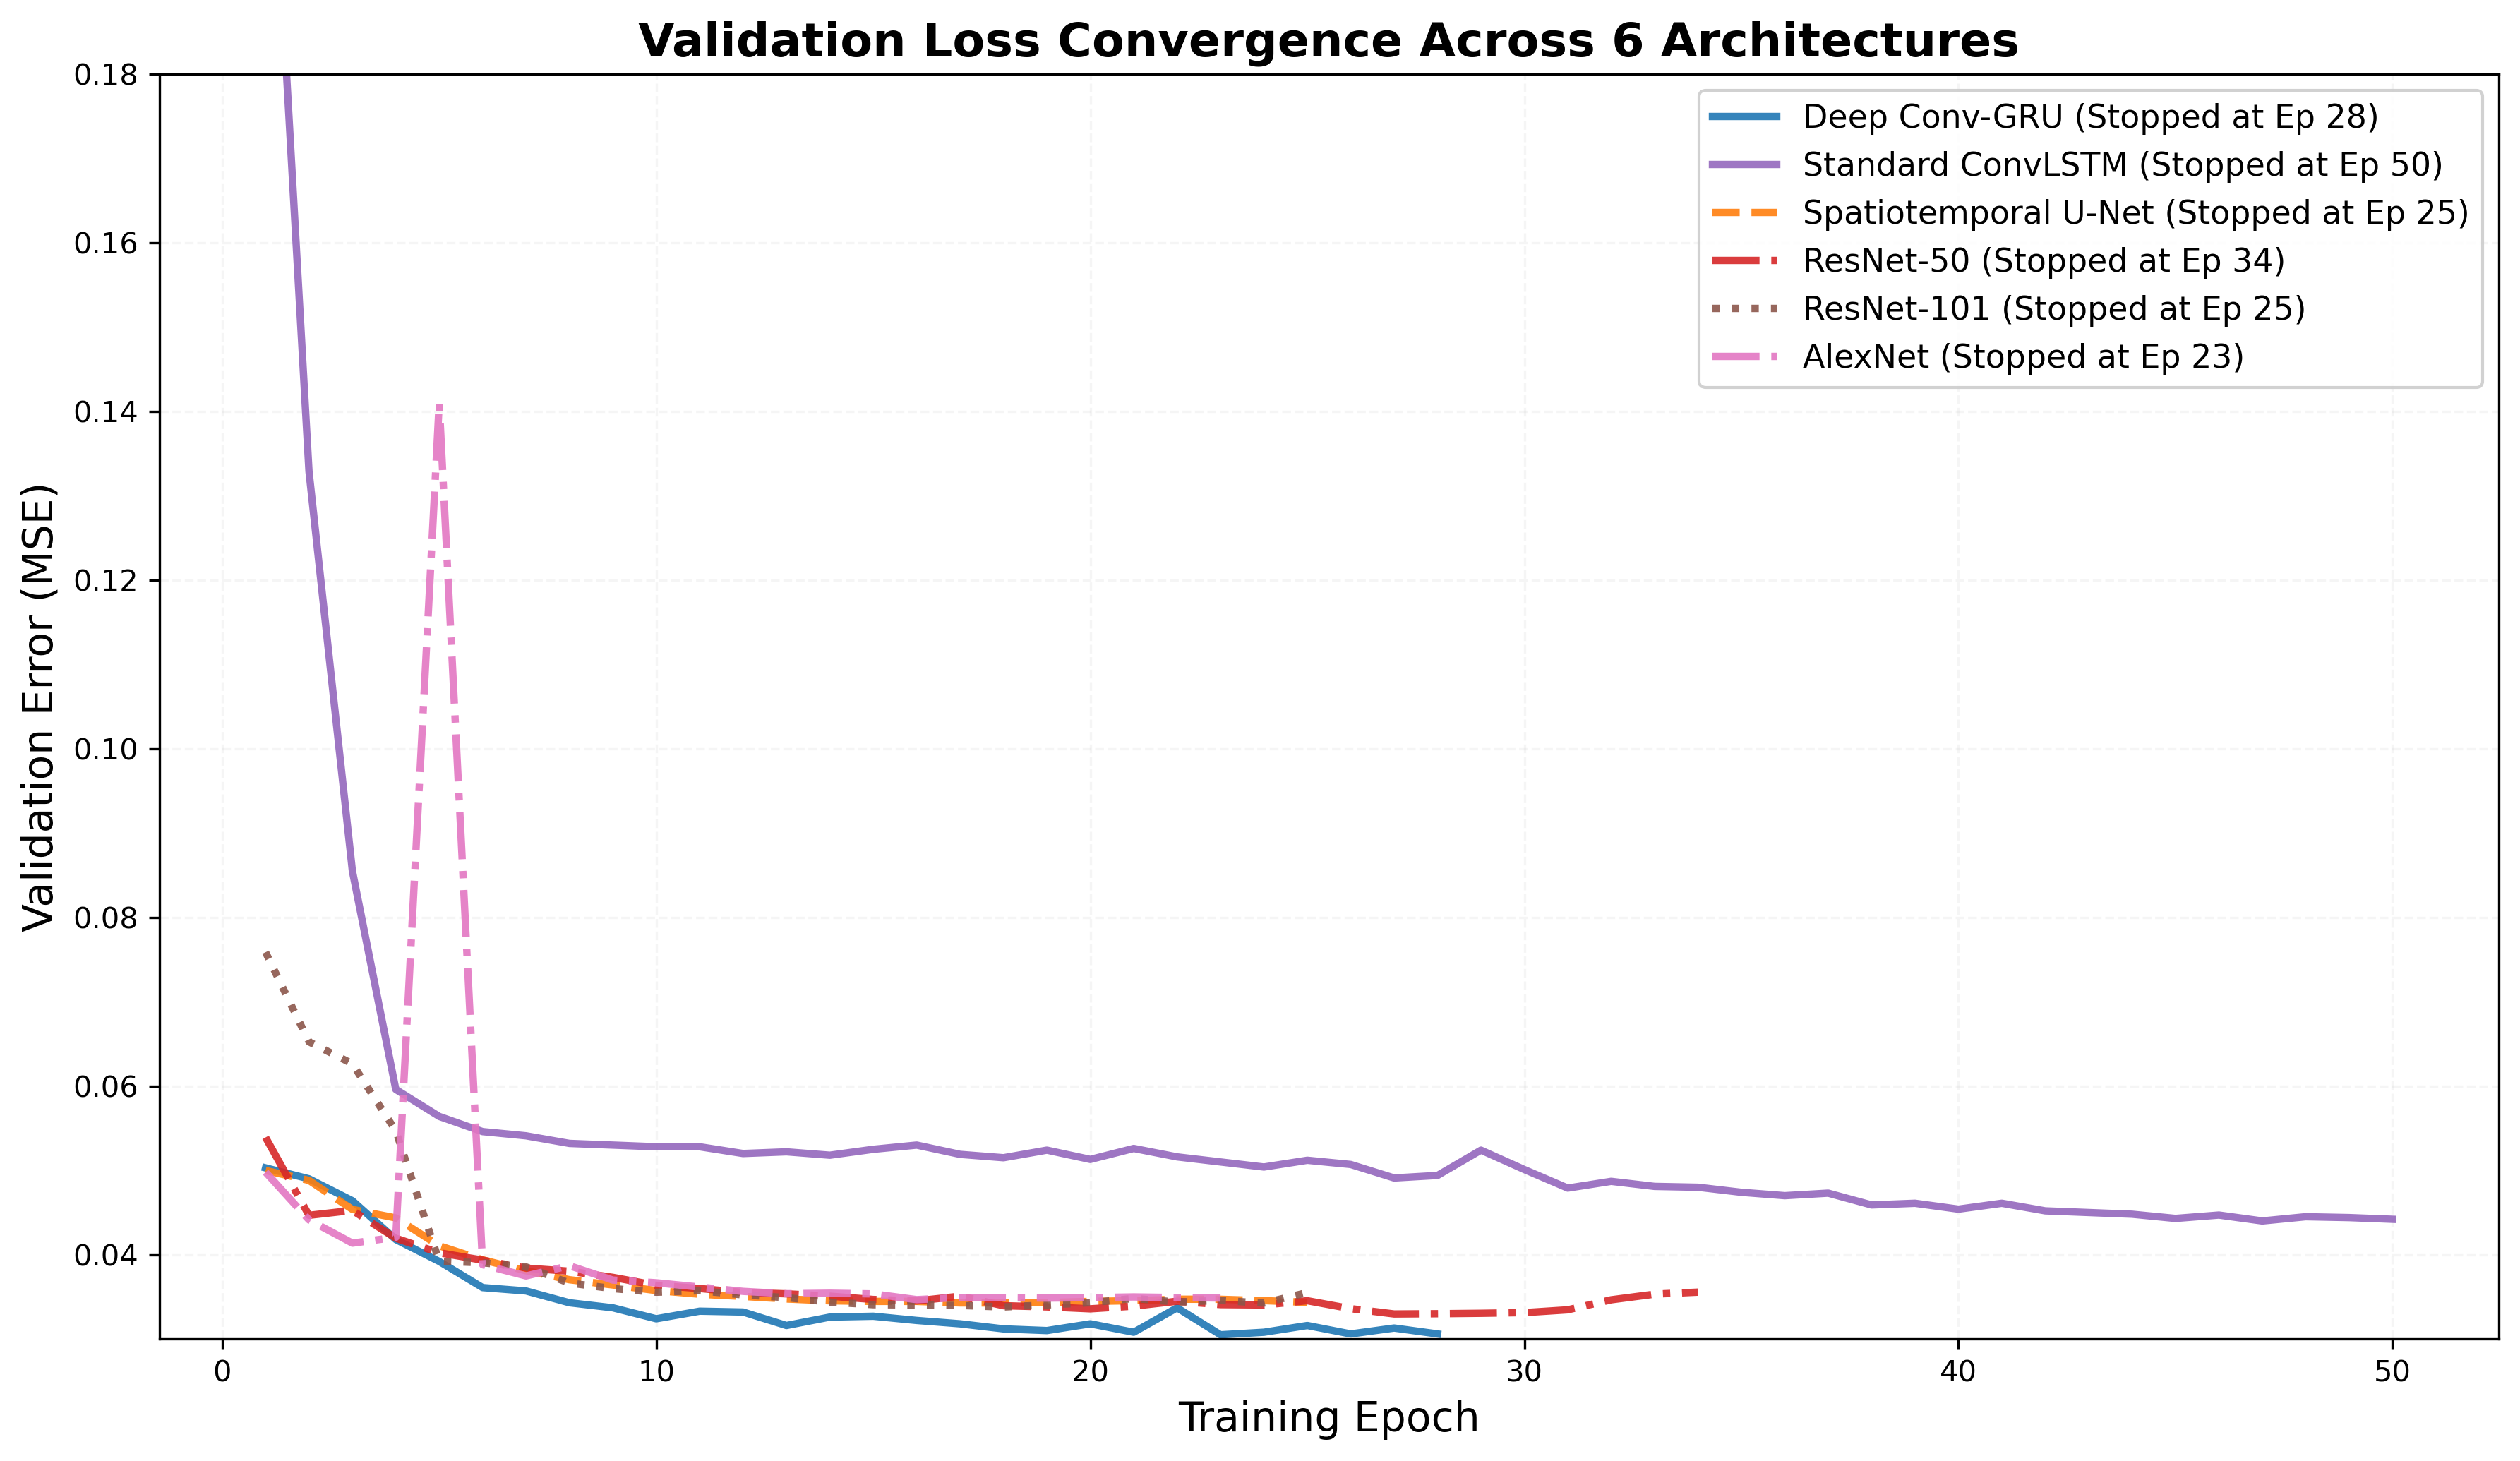


Master Graph successfully generated and saved!


In [1]:
import matplotlib.pyplot as plt
import re
import os

# ==========================================
# 1. SETUP THE LOG FILES
# Ensure these names exactly match the files in your folder
# ==========================================
log_files = {
    "Deep Conv-GRU": "CLEANED_convgru.txt",
    "Standard ConvLSTM": "CLEANED_convlstm.txt",
    "Spatiotemporal U-Net": "unet.txt",
    "ResNet-50": "resnet50.txt",
    "ResNet-101": "resnet101.txt",
    "AlexNet": "alexnet.txt"
}

# Distinct colors and line styles for a professional thesis aesthetic
styles = {
    "Deep Conv-GRU": {"color": "#1f77b4", "style": "-"},         # Solid Blue (The Winner)
    "Standard ConvLSTM": {"color": "#9467bd", "style": "-"},     # Solid Purple
    "Spatiotemporal U-Net": {"color": "#ff7f0e", "style": "--"}, # Dashed Orange
    "ResNet-50": {"color": "#d62728", "style": "-."},            # Dot-Dash Red
    "ResNet-101": {"color": "#8c564b", "style": ":"},            # Dotted Brown
    "AlexNet": {"color": "#e377c2", "style": "-."}               # Dot-Dash Pink
}

# ==========================================
# 2. AUTOMATIC PARSER & PLOTTER
# ==========================================
plt.figure(figsize=(12, 7), dpi=300)
print("Processing log files...")

for model_name, file_name in log_files.items():
    if os.path.exists(file_name):
        # Read the massive file safely (ignoring weird Kaggle text encoding errors)
        with open(file_name, 'r', encoding='utf-8', errors='ignore') as file:
            text = file.read()
            
            # Magical Regex: catches Keras 'val_loss: 0.05' AND Custom 'Val Loss: 0.05'
            matches = re.findall(r'(?:Val Loss:|val_loss:)\s*([0-9.]+)', text)
            
            if matches:
                # Convert the extracted text numbers into actual math floats
                loss_array = [float(x) for x in matches]
                epochs = list(range(1, len(loss_array) + 1))
                
                # Draw the line on the graph
                plt.plot(epochs, loss_array, 
                         label=f"{model_name} (Stopped at Ep {len(loss_array)})", 
                         color=styles[model_name]["color"], 
                         linestyle=styles[model_name]["style"], 
                         linewidth=2.5, alpha=0.9)
                print(f" ✅ Success: {model_name} ({len(loss_array)} epochs extracted)")
            else:
                print(f" ⚠️ Warning: Found {file_name}, but couldn't locate 'val_loss' inside.")
    else:
        print(f" ❌ Error: Could not find file -> {file_name}")

# ==========================================
# 3. GRAPH FORMATTING
# ==========================================
plt.title('Validation Loss Convergence Across 6 Architectures', fontsize=16, fontweight='bold')
plt.xlabel('Training Epoch', fontsize=14)
plt.ylabel('Validation Error (MSE)', fontsize=14)

# Zoom in to see the separation between models clearly. 
# AlexNet had a huge spike at epoch 5 (0.141), and Standard ConvLSTM started very high (0.224).
# This limit zooms in on the important lower area where they all converge.
# (If you want to see the massive spikes, just put a # in front of the next line)
plt.ylim(0.030, 0.18)

# Adjust legend and grid
plt.legend(loc='upper right', fontsize=11, framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.12)
plt.tight_layout()

# Save it as a beautiful high-resolution image for your report!
plt.savefig('Master_Automated_Loss_Graph.png')
plt.show()

print("\nMaster Graph successfully generated and saved!")